In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report

# Load Dataset

In [10]:
df = pd.read_csv('Resume.csv')
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


# Check Category Distribution

In [12]:
df['Category'].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


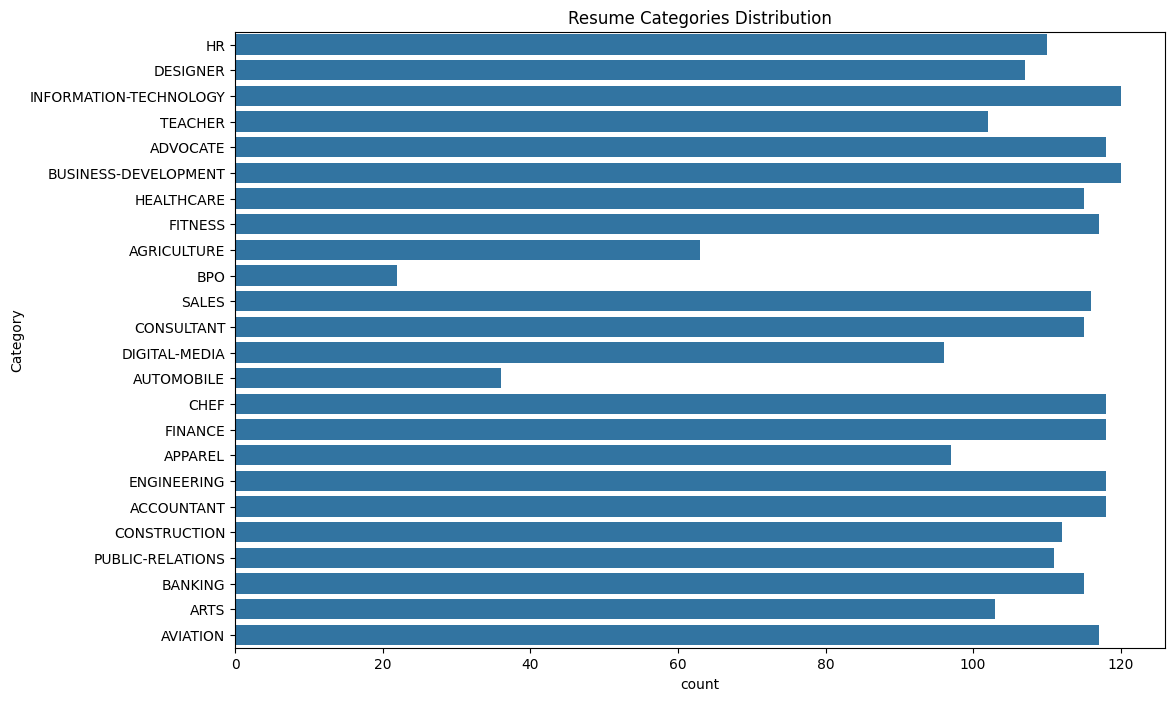

In [17]:
plt.figure(figsize=(12,8))
ax = sns.categorical.countplot(data=df, y='Category')
plt.title('Resume Categories Distribution')
plt.show()

# Text Cleaning

In [20]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'\n', '',text)
  text = re.sub(r'[^a-zA-Z ]','',text)

  return text

df['clean_resume'] = df['Resume_str'].apply(clean_text)

# Convert Text → Numerical Features


In [26]:
vectorizer = TfidfVectorizer(stop_words='english',max_features=15000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_resume'])

# Encode Target Labels

In [27]:
encoder = LabelEncoder()
y = encoder.fit_transform(df['Category'])

# Train Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size=0.2, stratify=y, random_state=42)

# Train Model


In [29]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Prediction

In [30]:
pred = model.predict(X_test)
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.65      0.83      0.73        24
           1       0.36      0.54      0.43        24
           2       1.00      0.38      0.56        13
           3       0.60      0.16      0.25        19
           4       0.58      0.33      0.42        21
           5       0.00      0.00      0.00         7
           6       0.81      0.71      0.76        24
           7       0.75      0.65      0.70        23
           8       0.00      0.00      0.00         4
           9       0.55      0.92      0.69        24
          10       0.86      0.75      0.80        24
          11       0.81      0.77      0.79        22
          12       0.50      0.22      0.30        23
          13       0.82      0.86      0.84        21
          14       0.77      0.53      0.62        19
          15       0.69      0.75      0.72        24
          16       0.89      0.67      0.76        24
          17       0.94    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
